In [1]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import itertools
import seaborn as sns
from sklearn.manifold import TSNE
import pickle as pkl
from sklearn.decomposition import PCA

In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})
# val_pred = pd.read_csv('../data/model_outputs/fusion_val_pred_df.csv')
test_pred = pd.read_csv('../data/model_outputs/ensemble_logis_test_pred.csv')

In [3]:
gru_val_pred = pd.read_csv('../data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('../data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

In [4]:
# val_pred = val_pred[val_pred.curve_idx.isin(gru_val_pred.curve_idx)]
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

In [44]:
groundtruth_df.head()

,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,groundtruth_label,encoded_igi_call
0,24933,S gene,Negative Control (qPCR),S252611,Negative,1,195418.72,195418.718750,-1,train,0,0
1,24933,S gene,Negative Control (qPCR),S252611,Negative,2,195288.33,195288.328125,-1,train,0,0
2,24933,S gene,Negative Control (qPCR),S252611,Negative,3,194651.67,194651.671875,-1,train,0,0
3,24933,S gene,Negative Control (qPCR),S252611,Negative,4,194355.02,194355.015625,-1,train,0,0
4,24933,S gene,Negative Control (qPCR),S252611,Negative,5,194165.97,194165.968750,-1,train,0,0


In [5]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))


In [6]:
# val_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'val', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
#            .merge(val_pred, how='inner', on = 'curve_idx'))
# val_pred_df = val_pred_df.rename(columns={'prob':'outputs'})
# test_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
#            .merge(test_pred, how='inner', on = 'curve_idx'))
test_pred_df = (groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})


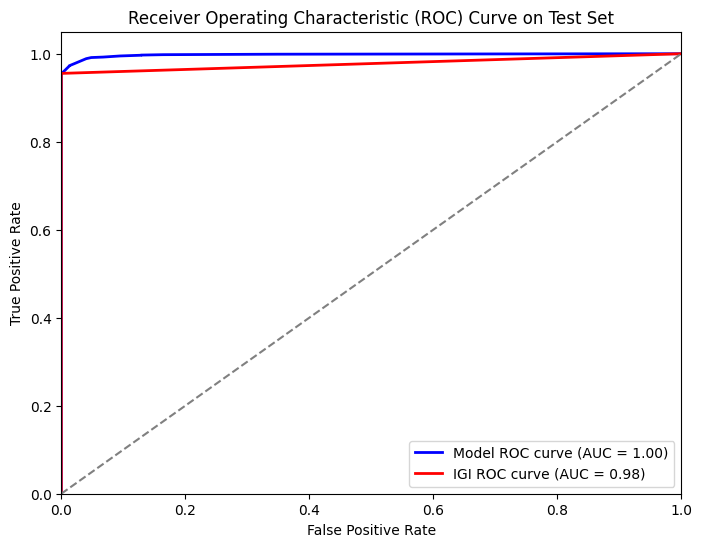

In [7]:
test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


## Test set

In [8]:
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call).ravel()

igi_precision = tp/(fp + tp)
igi_recall = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)
igi_acc = (tp+tn)/(tp+tn+fp+fn)
igi_neg_pred = sum(test_pred_df.encoded_igi_call == 0)

print('IGI AUC:', test_igi_auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)
print('IGI accuracy:', igi_acc)

IGI AUC: 0.9776389643309795
True negative, false positive, false negative, true positive: 621 0 247 5276
IGI negative predictions: 868
IGI precision score: 1.0
IGI recall score: 0.955277928661959
IGI specificity: 1.0
IGI F1: 0.9771275118066488
IGI accuracy: 0.9597981770833334


In [11]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
neg_preds, tnrs, precisions, recalls = [], [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    neg_preds.append(sum(pred == 0))
    tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, pred).ravel()
    # tnrs.append(sum((test_pred_df.groundtruth_label == 0) & (test_pred_df.groundtruth_label == pred)))
    # precisions.append(precision_score(test_pred_df.groundtruth_label, pred))
    # recalls.append(recall_score(test_pred_df.groundtruth_label, pred))

threshold_idx = neg_preds.index(874)
matched_thres = thresholds[threshold_idx]
matched_pred = 1*(test_pred_df.outputs >= matched_thres)
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, matched_pred).ravel()

precision = tp/(fp + tp)
recall = tp/(tp + fn)
specificity = tn/(tn + fp)
f1 = 2*tp/(2*tp + fp + fn)
acc = (tp+tn)/(tp+tn+fp+fn)

print('Model AUC:', test_auc)
print('Threshold to match IGI true negatives:', matched_thres)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('With matching threshold, model precision:', precision)
print('With matching threshold, model recall:', recall)
print('With matching threshold, model specificity:', specificity)
print('With matching threshold, model F1:', f1)
print('With matching threshold, model accuracy:', acc)

# # Create a plot
# plt.figure(figsize=(8, 6))
# plt.plot(thresholds, precisions, label='Model Precision')
# plt.plot(thresholds, recalls, label='Model Recall')
# plt.axhline(igi_precision, color = 'black', linestyle='--')
# plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, igi_precision), xytext=(0.15, igi_precision))
# plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
# plt.axhline(recalls[threshold_idx], color = 'black', linestyle='--')
# plt.annotate(f'Model Recall = {recalls[threshold_idx]}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*1.001))
# plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*0.996))
# plt.xlabel("Threshold")
# plt.ylabel("Rate")
# plt.ylim((0.85,1.02))
# plt.title("Precision and Recall vs. Threshold on Test Set")
# plt.legend(loc='lower left')
# plt.grid(True)
# plt.show()


Model AUC: 0.9976944605533352
Threshold to match IGI true negatives: 0.9864864864864865
True negative, false positive, false negative, true positive: 621 0 253 5270
With matching threshold, model precision: 1.0
With matching threshold, model recall: 0.9541915625565816
With matching threshold, model specificity: 1.0
With matching threshold, model F1: 0.9765588807560456
With matching threshold, model accuracy: 0.9588216145833334


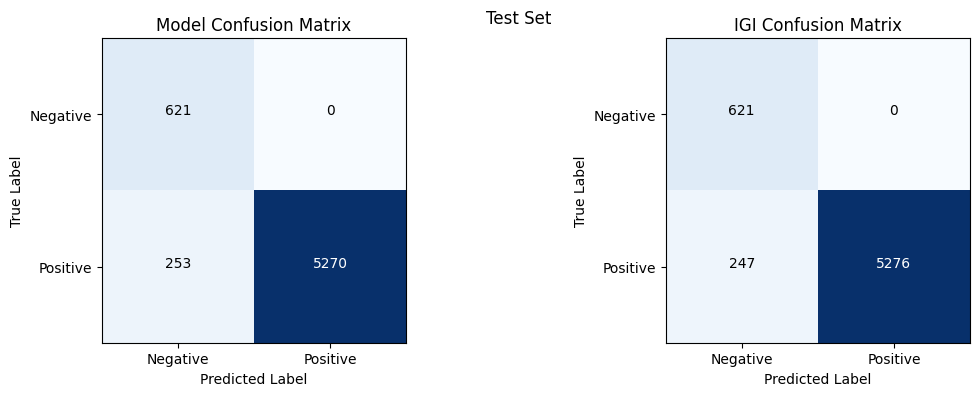

In [12]:
matched_preds = 1*(test_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(test_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
fig.suptitle('Test Set')
plt.show()


In [13]:
test_pred_df.loc[:,['matched_pred']] = matched_preds
print('Model confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.matched_pred)))
print('IGI confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.encoded_igi_call)))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       621
           1       1.00      0.95      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.90      6144
weighted avg       0.97      0.96      0.96      6144

IGI confusion matrix
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       621
           1       1.00      0.96      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.91      6144
weighted avg       0.97      0.96      0.96      6144



In [14]:

diff_df = (test_pred_df
           .loc[test_pred_df.encoded_igi_call != test_pred_df.matched_pred])
           
diff_df.loc[:,'matched_pred_val'] = diff_df.matched_pred.replace({1:'Positive',0:'Negative'})
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 6


/tmp/ipykernel_1353755/3801373310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_df.loc[:,'matched_pred_val'] = diff_df.matched_pred.replace({1:'Positive',0:'Negative'})


,curve_idx,groundtruth_label,encoded_igi_call,outputs,target,sample_id,final_patient_result,current_sample_result,sample_type,record_type,retest_sample_id_1,matched_pred,matched_pred_val
390,103226,1,1,0.210208,E gene,S1092315,NaN,NaN,Positive Control (qPCR),Control Sample,,0,Negative
393,103250,1,1,0.210208,E gene,S1092317,NaN,NaN,Positive Control (qPCR),Control Sample,,0,Negative
662,52922,1,1,0.963444,N gene,S488219,NaN,NaN,Positive Control (qPCR),Control Sample,,0,Negative
665,52946,1,1,0.939006,N gene,S680677,NaN,NaN,Positive Control (qPCR),Control Sample,,0,Negative
668,52948,1,1,0.963444,N gene,S680678,NaN,NaN,Positive Control (qPCR),Control Sample,,0,Negative


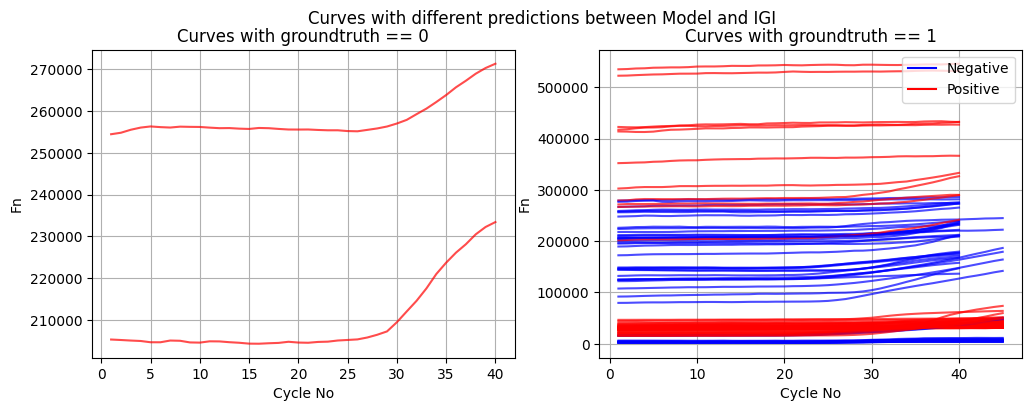

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            axes[0].plot(x,y, color = 'blue', alpha = 0.7)
        else:
            axes[0].plot(x,y, color = 'red', alpha = 0.7)
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue', alpha = 0.7)
        else:
            axes[1].plot(x,y, color = 'red', alpha = 0.7)

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.legend()
plt.show()

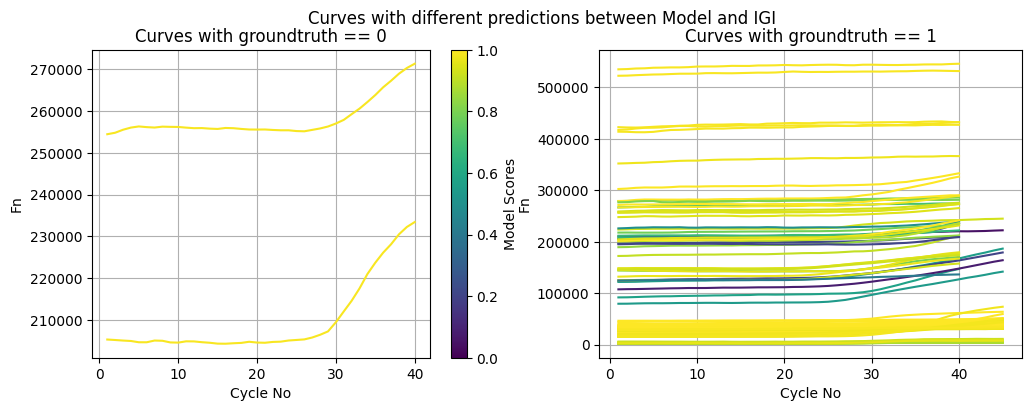

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1) #, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1) #, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax=axes[0])
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()

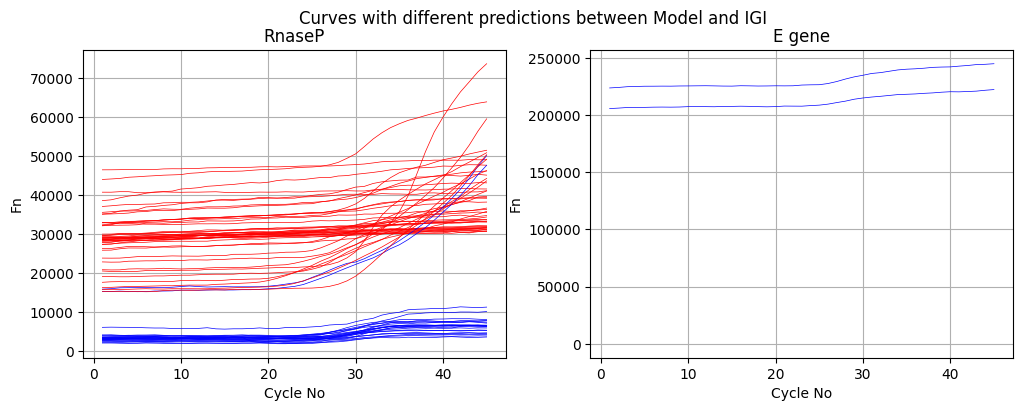

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    
    if df['target'].values == 'RnaseP':
        if df['matched_pred'].values == 0:
            axes[0].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[0].plot(x,y, color = 'red', lw = 0.5)

    elif df['target'].values == 'E gene':
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[1].plot(x,y, color = 'red', lw = 0.5)
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('RnaseP')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('E gene')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()


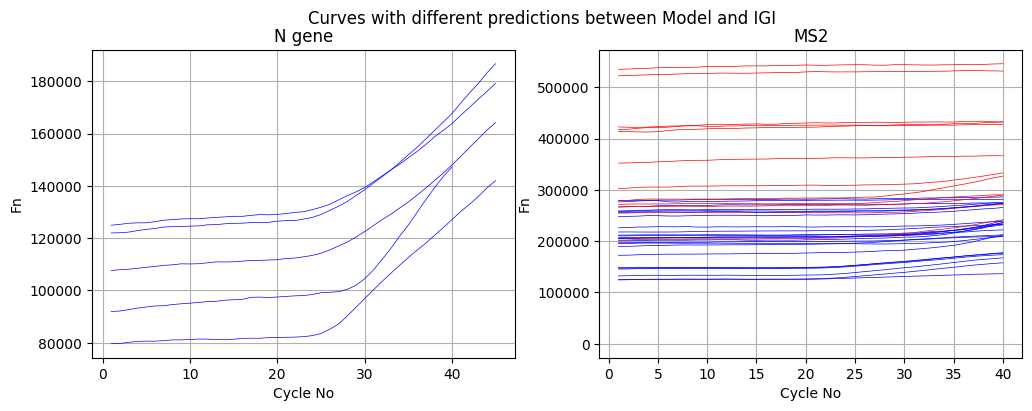

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    
    if df['target'].values == 'N gene':
        if all(df['matched_pred'].values == 0):
            axes[0].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[0].plot(x,y, color = 'red', lw = 0.5)

    elif df['target'].values == 'MS2':
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[1].plot(x,y, color = 'red', lw = 0.5)
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('N gene')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('MS2')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()


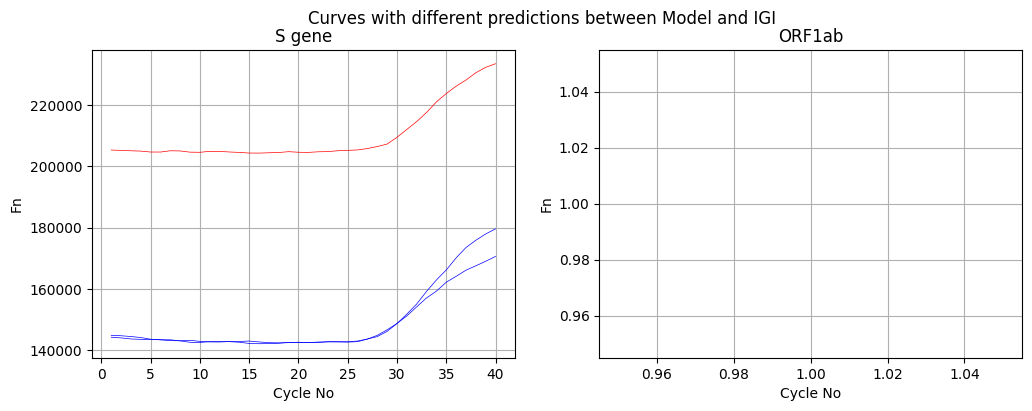

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    
    if df['target'].values == 'S gene':
        if all(df['matched_pred'].values == 0):
            axes[0].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[0].plot(x,y, color = 'red', lw = 0.5)

    elif df['target'].values == 'ORF1ab':
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[1].plot(x,y, color = 'red', lw = 0.5)
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('S gene')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('ORF1ab')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()


## Sample level classification

In [15]:
sample_df = (test_pred_df
             .loc[~test_pred_df.target.isin(['MS2','RnaseP'])]
             .groupby(['sample_id','final_patient_result','current_sample_result','sample_type'])
             .agg(n_curves = ('curve_idx', 'count'),
                  igi_call = ('encoded_igi_call', lambda x: int(np.mean(x))),
                  model_pred = ('matched_pred', lambda x: int(np.mean(x))))
             .reset_index())
sample_df.head()

,sample_id,final_patient_result,current_sample_result,sample_type,n_curves,igi_call,model_pred
0,S136857,Negative,Negative,Human Normal Negative Control (Extraction),3,0,0
1,S141969,Negative,Negative,Human Normal Negative Control (Extraction),3,0,0
2,S141970,Negative,Negative,Human Normal Negative Control (Extraction),3,0,0
3,S143151,Negative,Negative,Human Normal Negative Control (Extraction),3,0,0
4,S143161,ReSample,Invalid,Human Normal Negative Control (Extraction),3,0,0


### For model with gene

Number of predicted IGI false positive: 0
Number of predicted IGI false negative: 195


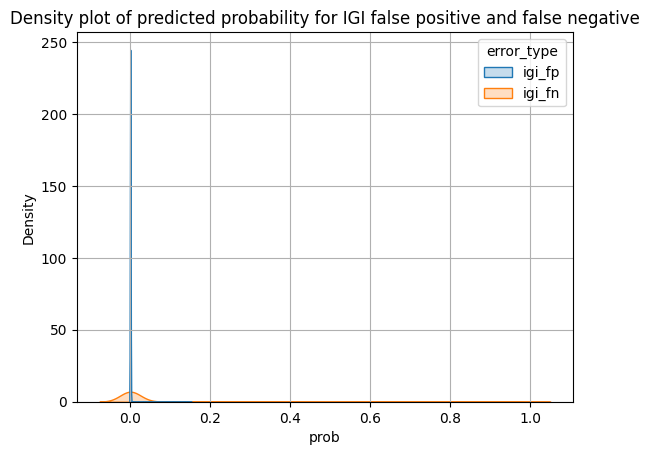

In [199]:
## For model fusion with gene
print(f'Number of predicted IGI false positive: {sum(test_pred_df.igi_fp >= 0.5)}')
print(f'Number of predicted IGI false negative: {sum(test_pred_df.igi_fn >= 0.5)}')

igi_fp_fn = pd.melt(test_pred_df[['curve_idx','igi_fp','igi_fn']], 
                    id_vars=['curve_idx'], 
                    value_vars=['igi_fp','igi_fn'], 
                    var_name='error_type',
                    value_name='prob')
sns.kdeplot(igi_fp_fn, x='prob', hue='error_type', fill=True)
plt.title('Density plot of predicted probability for IGI false positive and false negative')
plt.grid()
plt.show()


## Latent clustering

## Fusion
### Full test data

In [204]:
# load latent
with open('../data/model_outputs/fusion_vit_latent.pkl', 'rb') as file:
    latent_dict = pkl.load(file)

# diff_ids = pd.Series(latent_dict['curve_ids']).isin(diff_df.curve_idx)
# latent = latent_dict['latent'][diff_ids[diff_ids].index,:]

diff_ids = pd.Series(latent_dict['curve_ids']).isin(gru_test_pred.curve_idx)
latent = latent_dict['latent'][diff_ids[diff_ids].index,:]


In [205]:
df = (join_df[['curve_idx','cycle_no','Fn','target','sample_type','record_type','retest_sample_id_1']]
                       .groupby(['curve_idx','target','sample_type','record_type','retest_sample_id_1'])
                       .cycle_no.max().reset_index())
df.loc[:,'test_kit'] = 'Thermo'
df.loc[df.cycle_no == 45,'test_kit'] = 'LuNER'
df.loc[:, 'retest'] = df.retest_sample_id_1 != ' '
test_pred_2 = (test_pred_df
               .merge(df,how = 'inner', on = 'curve_idx'))

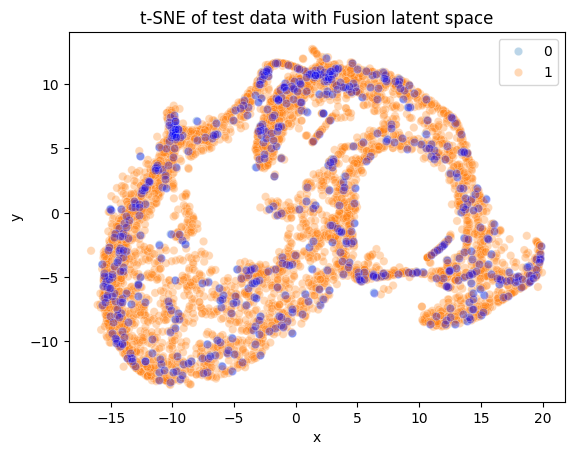

In [206]:
tsne = TSNE(n_components=3, random_state=42, perplexity=100)
X_tsne = tsne.fit_transform(latent)
tsne.kl_divergence_
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'groundtruth': test_pred_2.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='groundtruth', alpha = 0.3, data = tsne_df)
sns.scatterplot(x='x', y='y', color = 'blue', alpha=0.3, data = tsne_df[tsne_df.groundtruth == 0])
plt.title('t-SNE of test data with Fusion latent space')

plt.show()

Explained variation per principal component: [0.9784718  0.00934642 0.00602926]


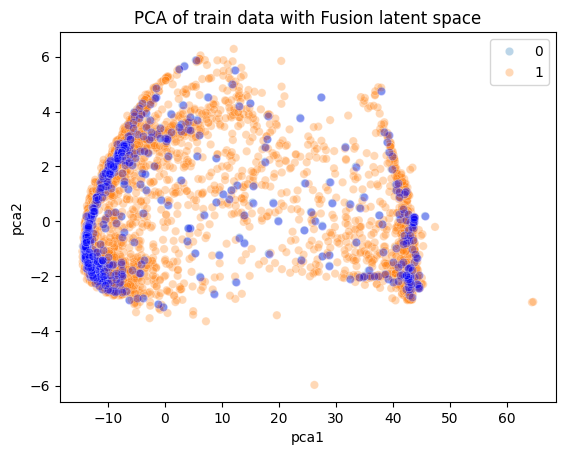

In [207]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'groundtruth': test_pred_2.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))

sns.scatterplot(x='pca1', y='pca2', hue='groundtruth', alpha = 0.3, data = pca_df)
sns.scatterplot(x='pca1', y='pca2', color = 'blue', alpha = 0.3, data = pca_df[pca_df.groundtruth == 0])
plt.title('PCA of train data with Fusion latent space')

plt.show()


### False predicted curves

In [114]:
fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label)]

false_ids = pd.Series(latent_dict['curve_ids']).isin(false_pred.curve_idx)
false_pred_latent = latent_dict['latent'][false_ids[false_ids].index,:]


KL divergence: 0.16755445301532745


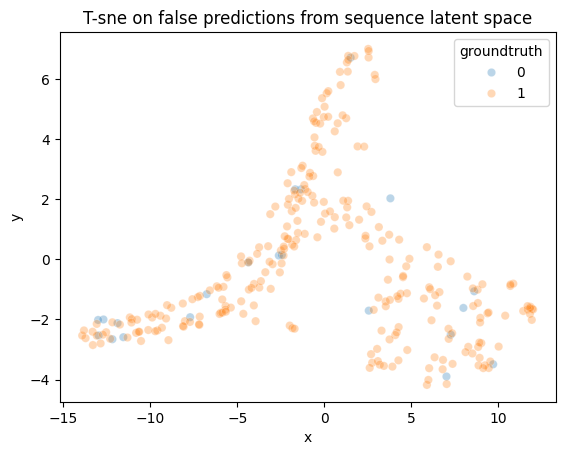

In [115]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'groundtruth': false_pred.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='groundtruth', alpha = 0.3, data = tsne_df)
plt.title('T-sne on false predictions from sequence latent space')
plt.show()

Explained variation per principal component: [0.817201   0.14483611 0.01352765]


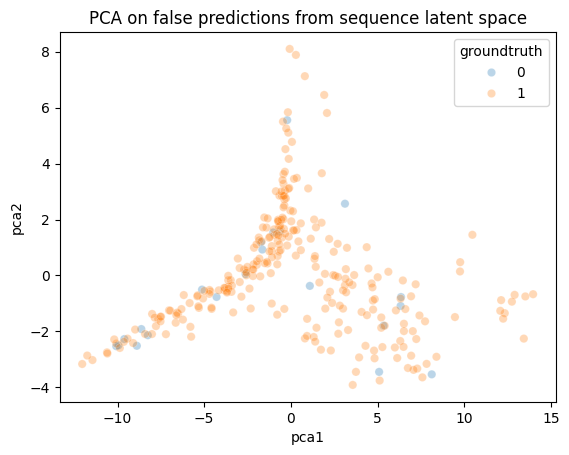

In [116]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'groundtruth': false_pred.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='groundtruth', alpha = 0.3, data = pca_df)
plt.title('PCA on false predictions from sequence latent space')
plt.show()

### False negatives

In [59]:
# fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
# fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_neg_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label) & (test_pred_2.matched_pred == 0)]

false_neg_ids = pd.Series(latent_dict['curve_ids']).isin(false_neg_pred.curve_idx)
false_neg_pred_latent = latent_dict['latent'][false_neg_ids[false_neg_ids].index,:]


KL divergence: 0.03621528670191765


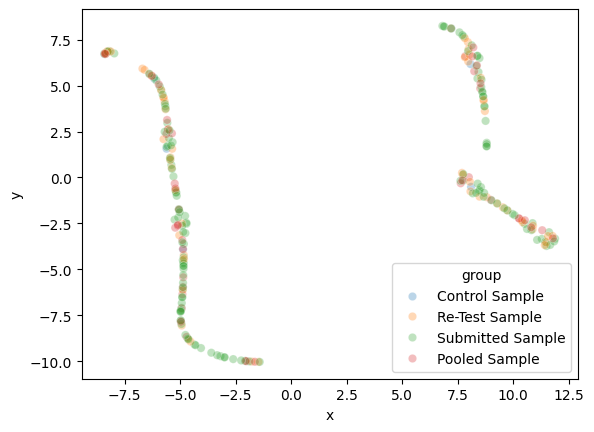

In [60]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_neg_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'group': false_neg_pred.record_type})
sns.scatterplot(x='x', y='y', hue='group', alpha = 0.3, data = tsne_df)
plt.show()

Explained variation per principal component: [0.81929916 0.17884453 0.00112309]


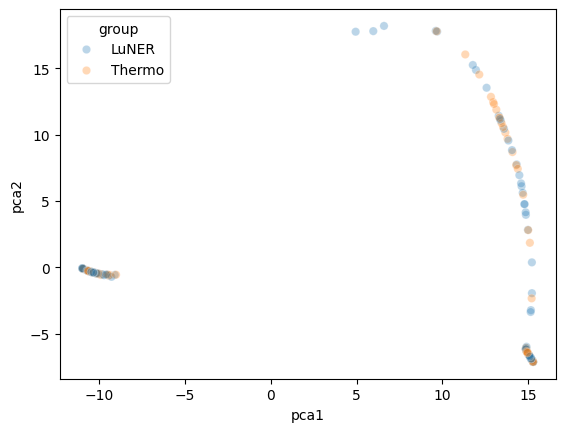

In [61]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_neg_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'group': false_neg_pred.test_kit})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='group', alpha = 0.3, data = pca_df)
plt.show()

## Fusion w gene
### IGI false negative

In [217]:
# load latent
with open('../data/model_outputs/fusion_latent.pkl', 'rb') as file:
    latent_dict = pkl.load(file)

# diff_ids = pd.Series(latent_dict['curve_ids']).isin(diff_df.curve_idx)
# latent = latent_dict['latent'][diff_ids[diff_ids].index,:]

diff_ids = pd.Series(latent_dict['curve_ids']).isin(gru_test_pred.curve_idx)
latent = latent_dict['latent'][diff_ids[diff_ids].index,:]


In [218]:
df = (join_df[['curve_idx','cycle_no','Fn','target','sample_type','record_type','retest_sample_id_1']]
                       .groupby(['curve_idx','target','sample_type','record_type','retest_sample_id_1'])
                       .cycle_no.max().reset_index())
df.loc[:,'test_kit'] = 'Thermo'
df.loc[df.cycle_no == 45,'test_kit'] = 'LuNER'
df.loc[:, 'retest'] = df.retest_sample_id_1 != ' '
test_pred_2 = (test_pred_df
               .merge(df,how = 'inner', on = 'curve_idx'))
test_pred_2['igi_fn_pred'] = 1*(test_pred_2.igi_fn >= 0.5)
test_pred_2['igi_fp_pred'] = 1*(test_pred_2.igi_fp >= 0.5)
print('Number of predicted IGI false negative:', sum(test_pred_2.igi_fn_pred))
print('Number of predicted IGI false positive:', sum(test_pred_2.igi_fp_pred))

Number of predicted IGI false negative: 195
Number of predicted IGI false positive: 0


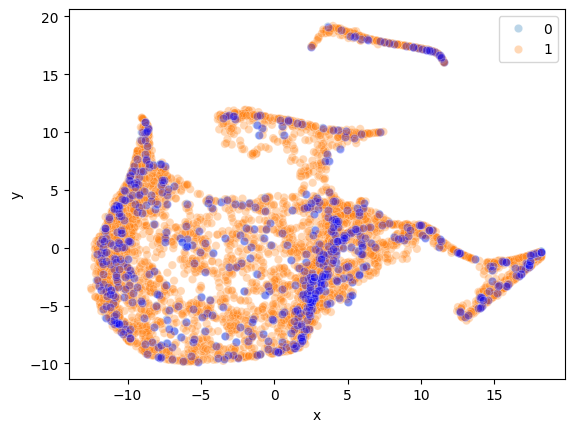

In [219]:
tsne = TSNE(n_components=3, random_state=42, perplexity=100)
X_tsne = tsne.fit_transform(latent)
tsne.kl_divergence_
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'group': test_pred_2.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='group', alpha = 0.3, data = tsne_df)
sns.scatterplot(x='x', y='y', color='blue', alpha = 0.3, data = tsne_df[tsne_df.group == 0])
plt.show()

Explained variation per principal component: [0.9285527  0.04124556 0.02763071]


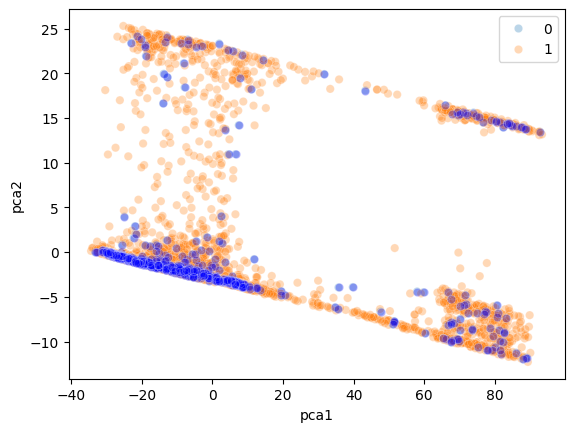

In [220]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'group': test_pred_2.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='group', alpha = 0.3, data = pca_df)
sns.scatterplot(x='pca1', y='pca2', color='blue', alpha = 0.3, data = pca_df[pca_df.group == 0])
plt.show()


### False predicted curves

In [221]:
fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label)]

false_ids = pd.Series(latent_dict['curve_ids']).isin(false_pred.curve_idx)
false_pred_latent = latent_dict['latent'][false_ids[false_ids].index,:]


KL divergence: 0.12288609892129898


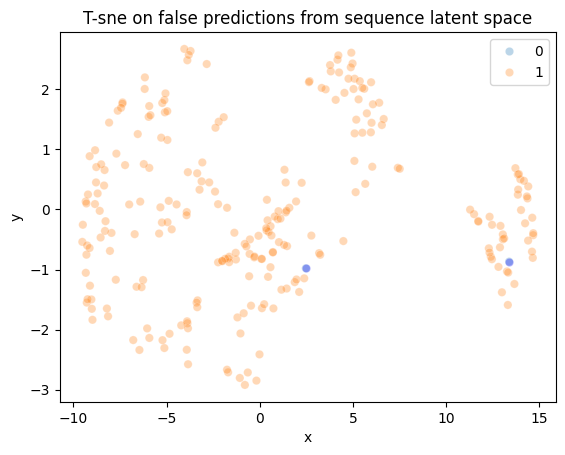

In [222]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'groundtruth': false_pred.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='groundtruth', alpha = 0.3, data = tsne_df)
sns.scatterplot(x='x', y='y', color='blue', alpha = 0.3, data = tsne_df[tsne_df.groundtruth == 0])
plt.title('T-sne on false predictions from sequence latent space')
plt.show()

Explained variation per principal component: [0.91173744 0.05858887 0.0267418 ]


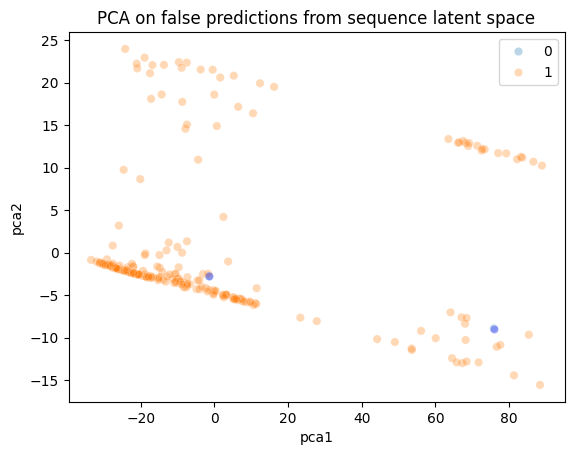

In [227]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'groundtruth': false_pred.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='groundtruth', alpha = 0.3, data = pca_df)
sns.scatterplot(x='pca1', y='pca2', color='blue', alpha = 0.3, data = pca_df[pca_df.groundtruth == 0])
plt.title('PCA on false predictions from sequence latent space')
plt.show()

### False negatives

In [ ]:
# fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
# fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_neg_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label) & (test_pred_2.matched_pred == 0)]

false_neg_ids = pd.Series(latent_dict['curve_ids']).isin(false_neg_pred.curve_idx)
false_neg_pred_latent = latent_dict['latent'][false_neg_ids[false_neg_ids].index,:]


KL divergence: 0.03621528670191765


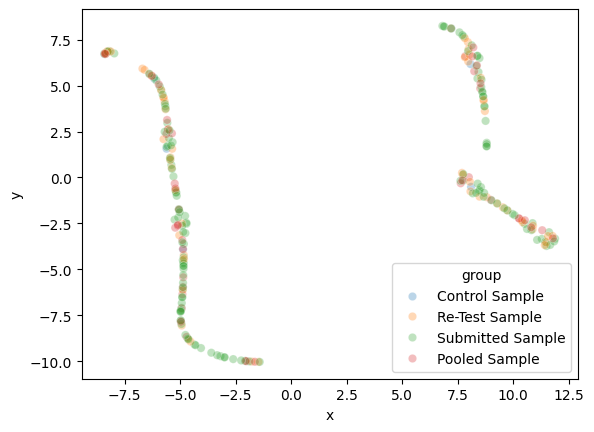

In [ ]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_neg_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'group': false_neg_pred.record_type})
sns.scatterplot(x='x', y='y', hue='group', alpha = 0.3, data = tsne_df)
plt.show()

Explained variation per principal component: [0.81929916 0.17884453 0.00112309]


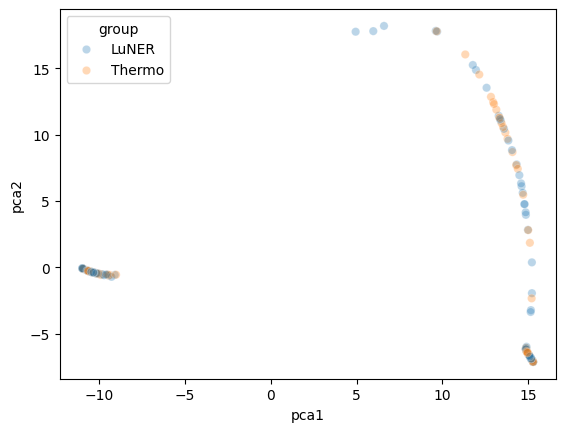

In [ ]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_neg_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'group': false_neg_pred.test_kit})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='group', alpha = 0.3, data = pca_df)
plt.show()

In [214]:
# fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
# fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
igi_false_neg_pred = test_pred_2[(test_pred_2.igi_fn_pred == 1)]

igi_false_neg_ids = pd.Series(latent_dict['curve_ids']).isin(igi_false_neg_pred.curve_idx)
igi_false_neg_pred_latent = latent_dict['latent'][igi_false_neg_ids[igi_false_neg_ids].index,:]


KL divergence: 0.026294050738215446


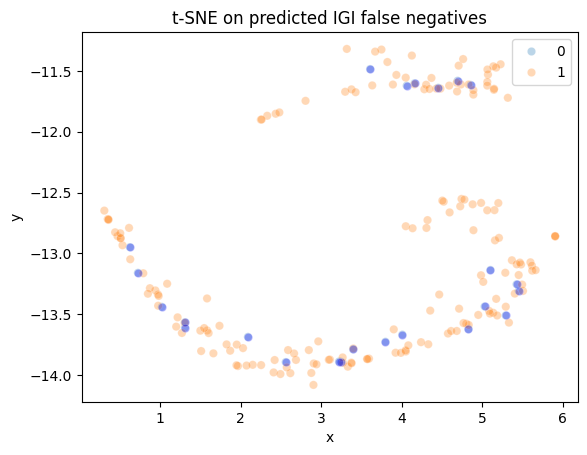

In [215]:
tsne = TSNE(n_components=3, random_state=42, perplexity=100)
X_tsne = tsne.fit_transform(igi_false_neg_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'groundtruth': igi_false_neg_pred.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='groundtruth', alpha = 0.3, data = tsne_df)
sns.scatterplot(x='x', y='y', color='blue', alpha = 0.3, data = tsne_df[tsne_df.groundtruth == 0])
plt.title('t-SNE on predicted IGI false negatives')
plt.show()

Explained variation per principal component: [0.6867344  0.15753014 0.1107873 ]


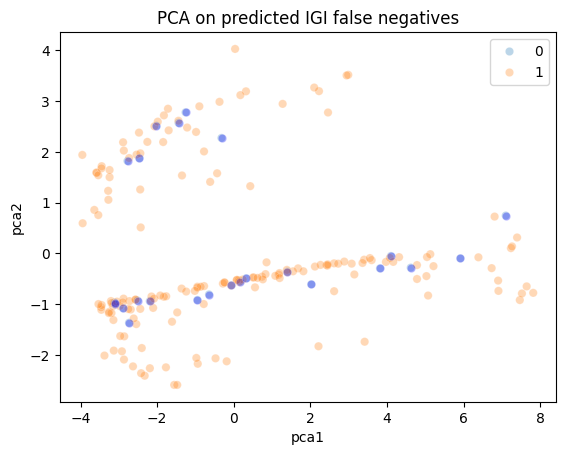

In [216]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(igi_false_neg_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'groundtruth': igi_false_neg_pred.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='groundtruth', alpha = 0.3, data = pca_df)
sns.scatterplot(x='pca1', y='pca2', color='blue', alpha = 0.3, data = pca_df[pca_df.groundtruth == 0])
plt.title('PCA on predicted IGI false negatives')
plt.show()

In [69]:
test_sample_df = (test_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

test_sample_df.loc[:,'sample_type'] = test_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
test_sample_pred = (test_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in Model prediction is: ', (sum(test_sample_pred.matched_pred.isin([0,1]))/test_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(test_sample_pred.encoded_igi_call.isin([0,1]))/test_sample_pred.shape[0]))

Agreement rate between genes in Model prediction is:  0.9758620689655172
Agreement rate between genes in IGI prediction is:  0.9896551724137931


### Other genes validation